<a href="https://colab.research.google.com/github/sokrypton/7.571/blob/main/L9/dim_reduction_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ Dimensionality Reduction — PCA, t-SNE, UMAP

All three methods try to make a 2D layout match the original data.  
They differ in **what forces** they apply:

| Method | Attraction | Repulsion |
|---|---|---|
| **PCA / MDS** | Preserve all distances | (implicit) |
| **t-SNE** | Pull similar points together | ✗ none |
| **UMAP** | Pull similar points together | Push dissimilar points apart |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.datasets import make_circles
from sklearn.metrics import pairwise_distances

## 0. Concentric Circles

Inner ring inside outer ring. Can each method separate them?

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


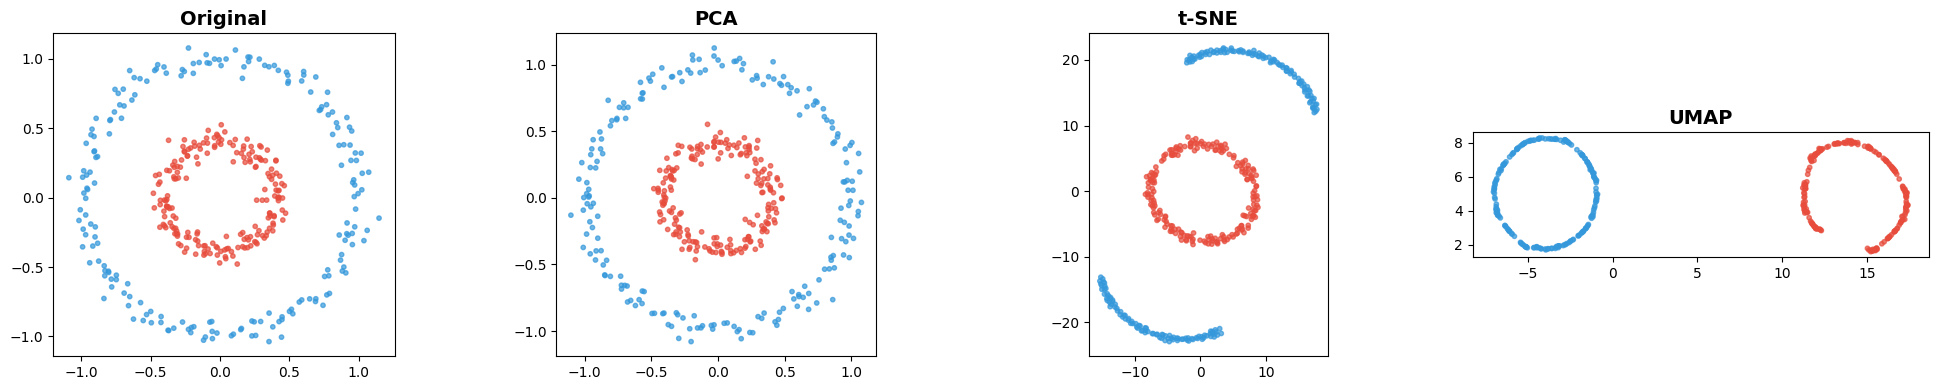

PCA: can't separate them — circles overlap in any linear projection.
t-SNE & UMAP: separate them by focusing on local neighborhoods.


In [2]:
X_circles, y_circles = make_circles(n_samples=400, factor=0.4, noise=0.05, random_state=42)

Z_pca  = PCA(2).fit_transform(X_circles)
Z_tsne = TSNE(2, perplexity=30, random_state=42).fit_transform(X_circles)
Z_umap = UMAP(n_components=2, n_neighbors=30, random_state=42).fit_transform(X_circles)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colors = ['#e74c3c' if yi == 1 else '#3498db' for yi in y_circles]

for ax, Z, name in zip(axes, [X_circles, Z_pca, Z_tsne, Z_umap],
                        ['Original', 'PCA', 't-SNE', 'UMAP']):
    ax.scatter(Z[:, 0], Z[:, 1], c=colors, s=10, alpha=0.7)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()
print('PCA: can\'t separate them — circles overlap in any linear projection.')
print('t-SNE & UMAP: separate them by focusing on local neighborhoods.')

---
## 1. PCA = Classical MDS

PCA (eigenvectors of covariance) and classical MDS (eigenvectors  
of double-centered distance matrix) give identical results.

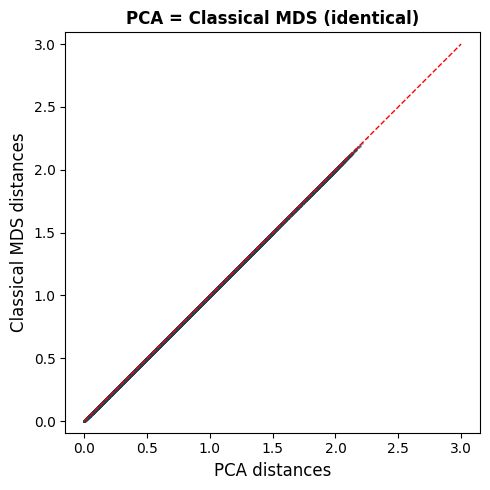

In [5]:
def classic_mds(X, n_components=2):
    """Classical MDS: eigendecompose the double-centered distance matrix."""
    D = pairwise_distances(X)
    L = D.shape[0]
    J = np.eye(L) - np.ones((L, L)) / L
    B = -0.5 * J @ (D ** 2) @ J
    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = np.maximum(evals[idx[:n_components]], 0)
    return evecs[:, idx[:n_components]] * np.sqrt(evals)

Z_pca = PCA(2).fit_transform(X_circles)
Z_mds = classic_mds(X_circles)

plt.figure(figsize=(5, 5))
plt.scatter(pairwise_distances(Z_pca).ravel(),
            pairwise_distances(Z_mds).ravel(), s=1, alpha=0.1, color='#2c3e50')
plt.plot([0, 3], [0, 3], 'r--', lw=1)
plt.xlabel('PCA distances', fontsize=12)
plt.ylabel('Classical MDS distances', fontsize=12)
plt.title('PCA = Classical MDS (identical)', fontweight='bold')
plt.axis('equal'); plt.tight_layout()
plt.show()

---
## 2. Mammoth

A 3D point cloud where the **global shape** (a mammoth silhouette)  
matters. Can each method preserve it when projecting to 2D?

In [ ]:
# Download mammoth 3D point cloud (10k points, from Google PAIR)
import json, urllib.request
url = 'https://raw.githubusercontent.com/PAIR-code/understanding-umap/master/raw_data/mammoth_3d.json'
mammoth_3d = np.array(json.loads(urllib.request.urlopen(url).read()))

np.random.seed(42)
X = mammoth_3d[np.random.choice(len(mammoth_3d), 2000, replace=False)]
print(f'Mammoth: {X.shape}')

Mammoth: (2000, 3)


In [ ]:
# Interactive 3D view (try rotating!)
import plotly.graph_objs as go

fig = go.Figure(data=[go.Scatter3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2],
    mode='markers', marker=dict(size=1.5, color=X[:, 1], colorscale='Viridis'))])
fig.update_layout(title='Mammoth 3D (colored by height)',
                  scene=dict(aspectmode='data'))
fig.show()

In [ ]:
Z_pca  = PCA(2).fit_transform(X)
Z_tsne = TSNE(2, perplexity=30, random_state=42).fit_transform(X)
Z_umap = UMAP(n_components=2, n_neighbors=30, random_state=42).fit_transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



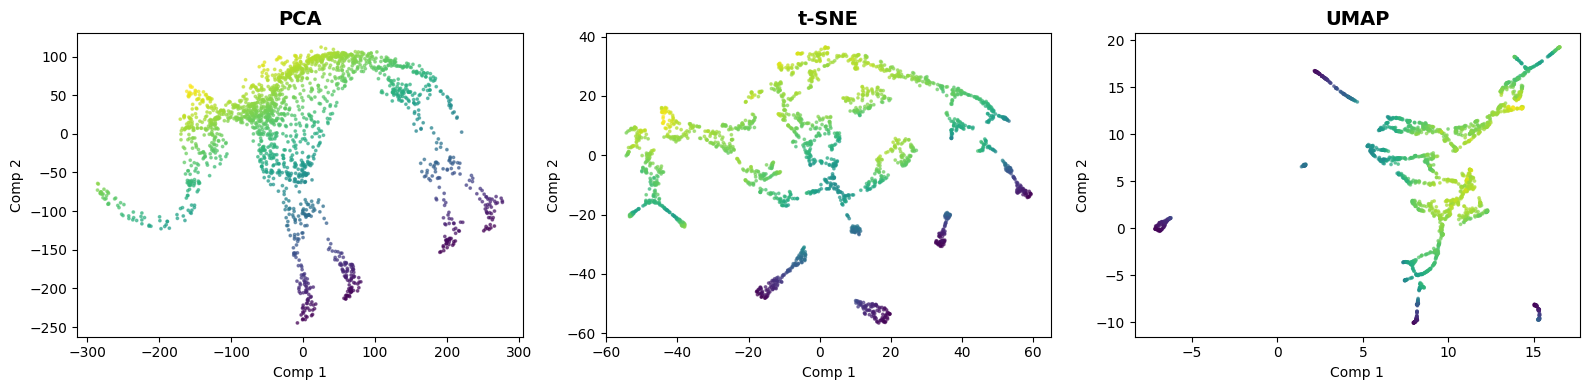

PCA: mammoth silhouette preserved (all distances maintained).
t-SNE: local structure OK but mammoth shape is torn apart.
UMAP: local structure OK, mammoth shape partially visible.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, Z, name in zip(axes, [Z_pca, Z_tsne, Z_umap], ['PCA', 't-SNE', 'UMAP']):
    ax.scatter(Z[:, 0], Z[:, 1], c=X[:, 1], cmap='viridis', s=3, alpha=0.6)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Comp 1'); ax.set_ylabel('Comp 2')

plt.tight_layout()
plt.show()
print('PCA: mammoth silhouette preserved (all distances maintained).')
print('t-SNE: local structure OK but mammoth shape is torn apart.')
print('UMAP: local structure OK, mammoth shape partially visible.')

### Distance preservation

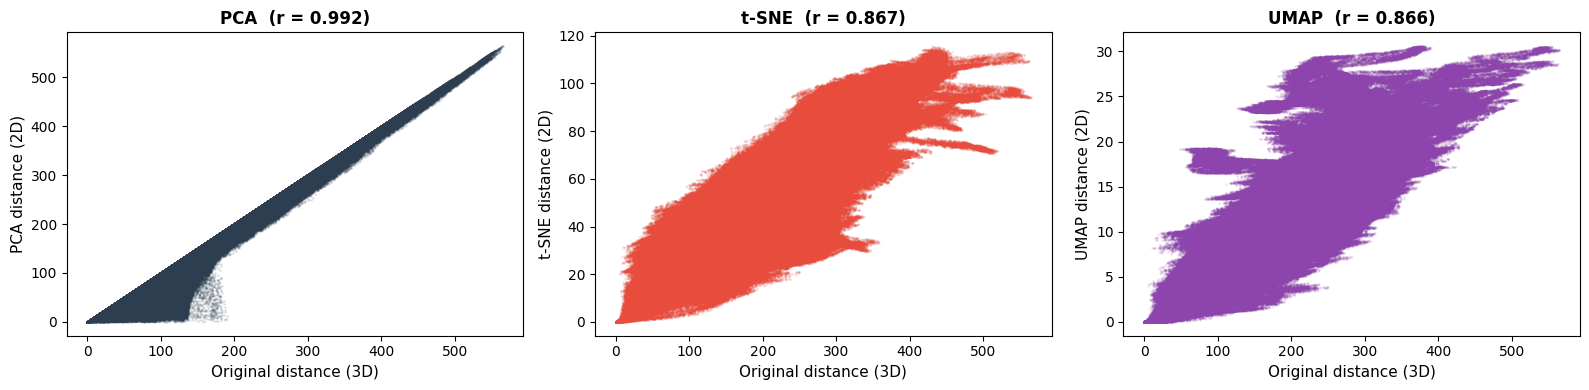

In [ ]:
d_original = pairwise_distances(X).ravel()
method_colors = ['#2c3e50', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, Z, name, color in zip(axes, [Z_pca, Z_tsne, Z_umap],
                               ['PCA', 't-SNE', 'UMAP'], method_colors):
    d_red = pairwise_distances(Z).ravel()
    corr = np.corrcoef(d_original, d_red)[0, 1]
    ax.scatter(d_original, d_red, s=1, alpha=0.05, color=color)
    ax.set_xlabel('Original distance (3D)', fontsize=11)
    ax.set_ylabel(f'{name} distance (2D)', fontsize=11)
    ax.set_title(f'{name}  (r = {corr:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Why Does t-SNE Scramble Global Structure?

Both t-SNE and UMAP convert distances into a **similarity matrix** P  
using a Gaussian kernel. Nearby points get high similarity,  
far points get ~0.

Then they optimize 2D coordinates to match these similarities.

The key difference is in the **loss function**:

```
t-SNE:  -Σ P · log(Q)                        attraction only
UMAP:   -Σ P · log(Q) - (1-P) · log(1-Q)     attraction + repulsion
```

**t-SNE only attracts:** "if two points are similar, pull them together."  
But there's no force pushing dissimilar points apart. So points that  
are far apart in the original space can end up anywhere — as long as  
the local neighborhoods are right, t-SNE is happy.

**UMAP adds repulsion:** "if two points are dissimilar, push them apart."  
This `-(1-P) · log(1-Q)` term penalizes placing far-apart points  
close together in 2D. The result: dissimilar points get actively  
pushed away from each other.

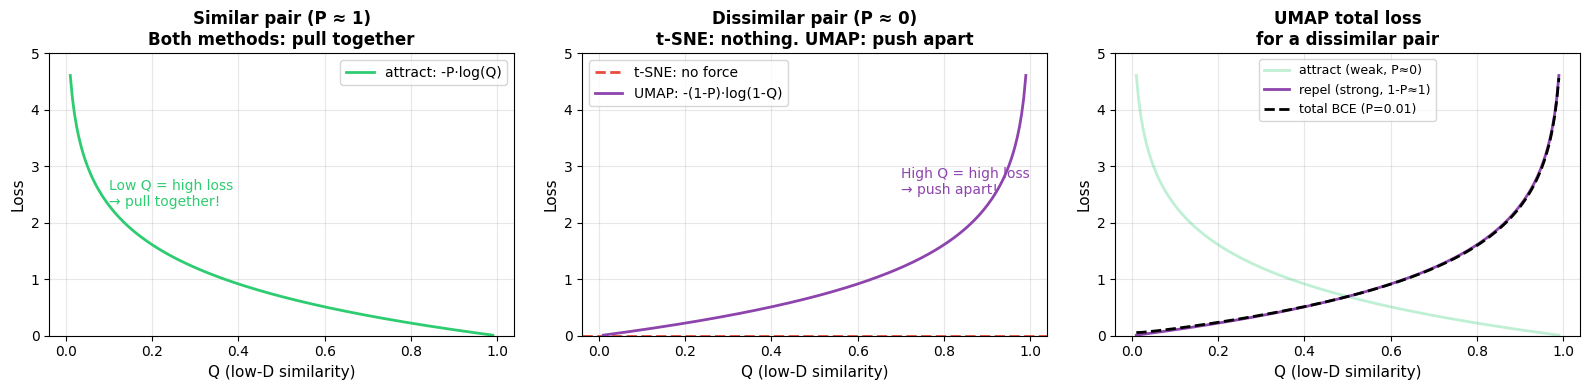

Left:  Both methods pull similar points together (low Q → high loss).
Middle: For dissimilar points, t-SNE does nothing. UMAP pushes apart (high Q → high loss).
Right: UMAP's full loss for a dissimilar pair — repulsion dominates.


In [ ]:
# Visualize attraction vs repulsion forces
q = np.linspace(0.01, 0.99, 200)  # Q: low-D similarity

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: what happens when P=1 (similar points) — both methods attract
axes[0].plot(q, -np.log(q), lw=2, color='#2ecc71', label='attract: -P·log(Q)')
axes[0].set_xlabel('Q (low-D similarity)', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Similar pair (P ≈ 1)\nBoth methods: pull together', fontweight='bold')
axes[0].set_ylim(0, 5); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate('Low Q = high loss\n→ pull together!',
                 xy=(0.1, 2.3), fontsize=10, color='#2ecc71')

# Middle: what happens when P=0 (dissimilar points) — only UMAP repels
axes[1].axhline(y=0, lw=2, color='#e74c3c', linestyle='--', label='t-SNE: no force')
axes[1].plot(q, -np.log(1 - q), lw=2, color='#8e44ad', label='UMAP: -(1-P)·log(1-Q)')
axes[1].set_xlabel('Q (low-D similarity)', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Dissimilar pair (P ≈ 0)\nt-SNE: nothing. UMAP: push apart', fontweight='bold')
axes[1].set_ylim(0, 5); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].annotate('High Q = high loss\n→ push apart!',
                 xy=(0.7, 2.5), fontsize=10, color='#8e44ad')

# Right: full BCE for a dissimilar pair
axes[2].plot(q, -np.log(q), lw=2, color='#2ecc71', alpha=0.3, label='attract (weak, P≈0)')
axes[2].plot(q, -np.log(1-q), lw=2, color='#8e44ad', label='repel (strong, 1-P≈1)')
axes[2].plot(q, -0.01*np.log(q) - 0.99*np.log(1-q), lw=2, color='black',
             linestyle='--', label='total BCE (P=0.01)')
axes[2].set_xlabel('Q (low-D similarity)', fontsize=11)
axes[2].set_ylabel('Loss', fontsize=11)
axes[2].set_title('UMAP total loss\nfor a dissimilar pair', fontweight='bold')
axes[2].set_ylim(0, 5); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Left:  Both methods pull similar points together (low Q → high loss).')
print('Middle: For dissimilar points, t-SNE does nothing. UMAP pushes apart (high Q → high loss).')
print('Right: UMAP\'s full loss for a dissimilar pair — repulsion dominates.')

---
## 4. The Similarity Matrix

Both t-SNE and UMAP first convert distances into similarities  
using a Gaussian kernel. The σ (width) is calibrated **per point**  
so each point has roughly the same number of effective neighbors.

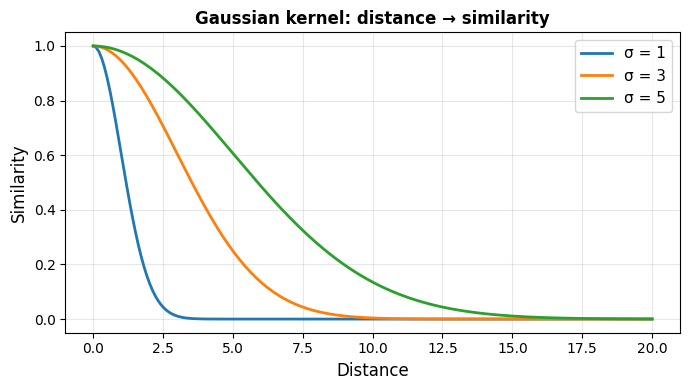

Beyond a certain radius, similarity → 0.
This is why t-SNE/UMAP focus on local structure.
The "radius" (σ) adapts per point — dense regions get small σ, sparse get large σ.


In [ ]:
# The Gaussian kernel: close → high similarity, far → ~0
distances = np.linspace(0, 20, 200)

plt.figure(figsize=(7, 4))
for sigma in [1, 3, 5]:
    plt.plot(distances, np.exp(-distances**2 / (2 * sigma**2)),
             lw=2, label=f'σ = {sigma}')
plt.xlabel('Distance', fontsize=12)
plt.ylabel('Similarity', fontsize=12)
plt.title('Gaussian kernel: distance → similarity', fontweight='bold')
plt.legend(fontsize=11); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Beyond a certain radius, similarity → 0.')
print('This is why t-SNE/UMAP focus on local structure.')
print('The "radius" (σ) adapts per point — dense regions get small σ, sparse get large σ.')

### Perplexity (t-SNE) ≈ n_neighbors (UMAP)

Both control the same thing: **how many neighbors each point effectively has.**

- t-SNE: σ calibrated so entropy of similarity row = log(perplexity)
- UMAP: finds literal k-nearest neighbors, then calibrates σ

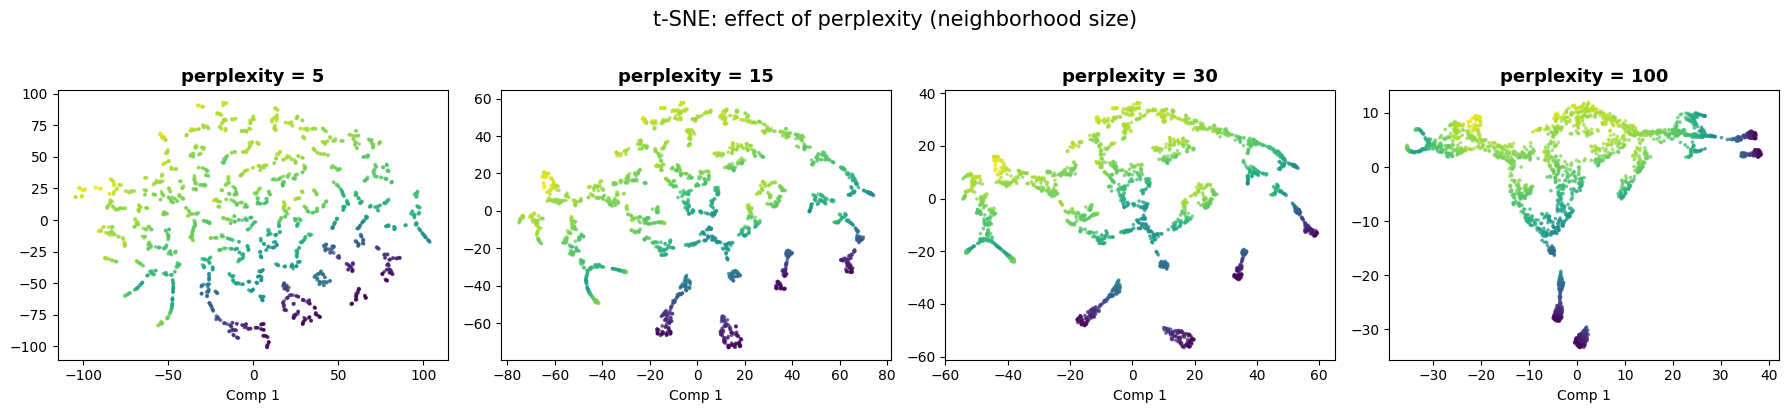

Low perplexity → tight local clusters. High perplexity → more global structure.


In [ ]:
# Effect of perplexity on t-SNE
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, perp in zip(axes, [5, 15, 30, 100]):
    Z = TSNE(2, perplexity=perp, random_state=42).fit_transform(X)
    ax.scatter(Z[:, 0], Z[:, 1], c=X[:, 1], cmap='viridis', s=3, alpha=0.6)
    ax.set_title(f'perplexity = {perp}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Comp 1')

plt.suptitle('t-SNE: effect of perplexity (neighborhood size)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print('Low perplexity → tight local clusters. High perplexity → more global structure.')

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



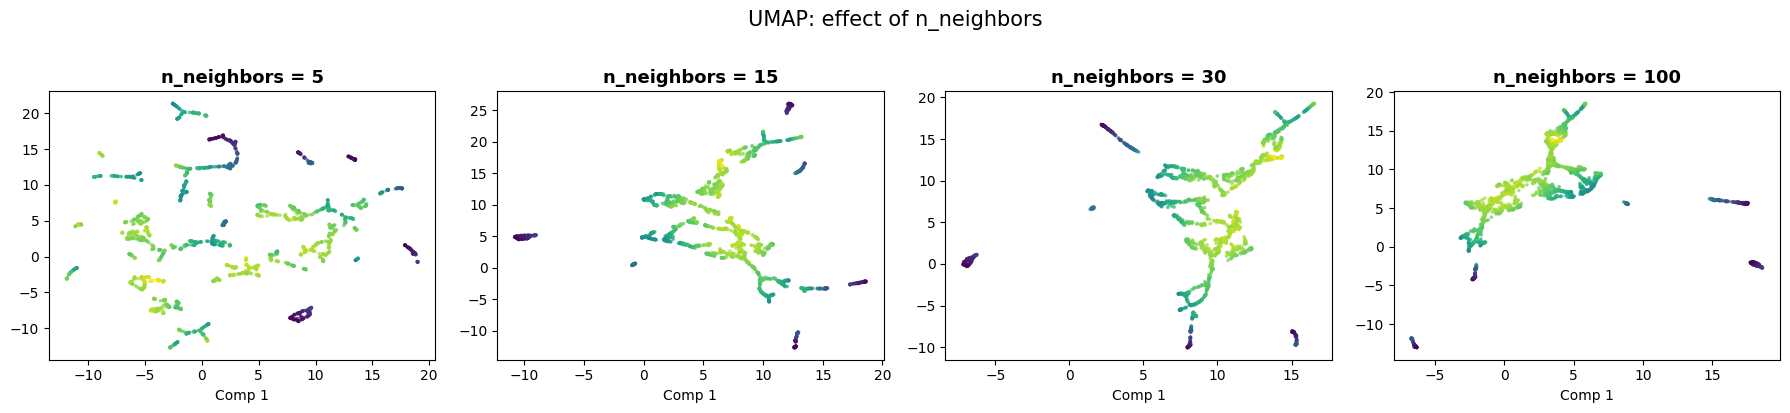

Same knob as perplexity — controls the locality of the embedding.


In [ ]:
# Effect of n_neighbors on UMAP
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, nn in zip(axes, [5, 15, 30, 100]):
    Z = UMAP(n_components=2, n_neighbors=nn, random_state=42).fit_transform(X)
    ax.scatter(Z[:, 0], Z[:, 1], c=X[:, 1], cmap='viridis', s=3, alpha=0.6)
    ax.set_title(f'n_neighbors = {nn}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Comp 1')

plt.suptitle('UMAP: effect of n_neighbors', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print('Same knob as perplexity — controls the locality of the embedding.')

---
## 📝 Summary

| | PCA / MDS | t-SNE | UMAP |
|---|---|---|---|
| **Approach** | Preserve distances | Convert to similarities, match them | Same as t-SNE |
| **Attraction** | Implicit (distance matching) | `-P · log(Q)` | `-P · log(Q)` |
| **Repulsion** | Implicit (distance matching) | ✗ None | `-(1-P) · log(1-Q)` |
| **Local structure** | OK | ✓ Great | ✓ Great |
| **Dissimilar points** | Kept apart (distances preserved) | Can drift anywhere | Actively pushed apart |

The missing repulsion in t-SNE means far-apart points have **no force**  
acting on them — they end up wherever is convenient for the local  
neighborhoods. UMAP's repulsion term explicitly pushes them away.